In [ ]:
import pandas as pd

solar = pd.read_csv(
    "/content/solar_forecasting_processed (1).csv",
    parse_dates=["Timestamp"]
)

solar = solar.sort_values("Timestamp").reset_index(drop=True)

print(solar.shape)
print(solar["Timestamp"].min())
print(solar["Timestamp"].max())

(17184, 23)
2012-07-08 00:00:00
2013-06-30 23:30:00


In [ ]:
solar["target"] = solar["Total_Solar_kWh"].shift(-1)

In [ ]:
solar = solar.dropna(subset=["target"]).reset_index(drop=True)

In [ ]:
feature_cols = [
    "hour",
    "minute",
    "day_of_week",
    "day_of_month",
    "month",
    "day_of_year",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "day_of_year_sin",
    "day_of_year_cos",
    "is_daylight",
    "lag_1",
    "lag_2",
    "lag_4",
    "lag_48",
    "lag_96",
    "lag_336",
    "rolling_mean_2",
    "rolling_mean_4",
    "rolling_mean_48"
]

X = solar[feature_cols]
y = solar["target"]

In [ ]:
n = len(solar)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
X_val   = X.iloc[train_end:val_end]
X_test  = X.iloc[val_end:]

y_train = y.iloc[:train_end]
y_val   = y.iloc[train_end:val_end]
y_test  = y.iloc[val_end:]

In [ ]:
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

print("\nTrain period:")
print(solar["Timestamp"].iloc[0], "→", solar["Timestamp"].iloc[train_end - 1])

print("\nValidation period:")
print(solar["Timestamp"].iloc[train_end], "→", solar["Timestamp"].iloc[val_end - 1])

print("\nTest period:")
print(solar["Timestamp"].iloc[val_end], "→", solar["Timestamp"].iloc[-1])

Train: (12028, 21) (12028,)
Validation: (2577, 21) (2577,)
Test: (2578, 21) (2578,)

Train period:
2012-07-08 00:00:00 → 2013-03-15 13:30:00

Validation period:
2013-03-15 14:00:00 → 2013-05-08 06:00:00

Test period:
2013-05-08 06:30:00 → 2013-06-30 23:00:00


In [ ]:
y_pred_persistence = solar["Total_Solar_kWh"].shift(0)

In [ ]:
test_indices = solar.index[val_end:]

y_pred_persistence = solar.loc[
    test_indices,
    "Total_Solar_kWh"
]

In [ ]:
y_test_actual = solar.loc[
    test_indices,
    "target"
]

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

baseline_mae = mean_absolute_error(
    y_test_actual,
    y_pred_persistence
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        y_pred_persistence
    )
)

baseline_r2 = r2_score(
    y_test_actual,
    y_pred_persistence
)

print("Persistence Baseline")
print("MAE :", baseline_mae)
print("RMSE:", baseline_rmse)
print("R²  :", baseline_r2)

Persistence Baseline
MAE : 4.444510085337471
RMSE: 8.279025592182476
R²  : 0.9529427573039377


Baseline Model->
Persistence Baseline
MAE : 4.444510085337471
RMSE: 8.279025592182476
R²  : 0.9529427573039377

In [ ]:
import xgboost as xgb
print(xgb.__version__)

3.4.1


In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print("XGBoost training complete.")

XGBoost training complete.


In [ ]:
y_pred_val = xgb_model.predict(X_val)

val_mae = mean_absolute_error(y_val, y_pred_val)
val_rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
val_r2 = r2_score(y_val, y_pred_val)
print("XGBoost Validation")
print("MAE :", val_mae)
print("RMSE:", val_rmse)
print("R²  :", val_r2)

XGBoost Validation
MAE : 3.764809102104281
RMSE: 7.3392017833702035
R²  : 0.9814306231611757


In [ ]:
importance = pd.Series(
    xgb_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)
print(importance)

lag_1              0.497915
hour_cos           0.286108
rolling_mean_2     0.064749
hour_sin           0.046821
hour               0.045421
lag_48             0.016414
day_of_year_cos    0.007327
rolling_mean_4     0.006661
lag_4              0.006176
lag_336            0.004566
month              0.002430
day_of_year        0.002254
lag_2              0.002133
lag_96             0.002053
day_of_year_sin    0.001872
rolling_mean_48    0.001845
day_of_month       0.001511
minute             0.001207
is_weekend         0.001187
day_of_week        0.001144
is_daylight        0.000205
dtype: float32


The model gets most of its predictive power from very recent generation and time-of-day information, while longer historical/seasonal features contribute much less

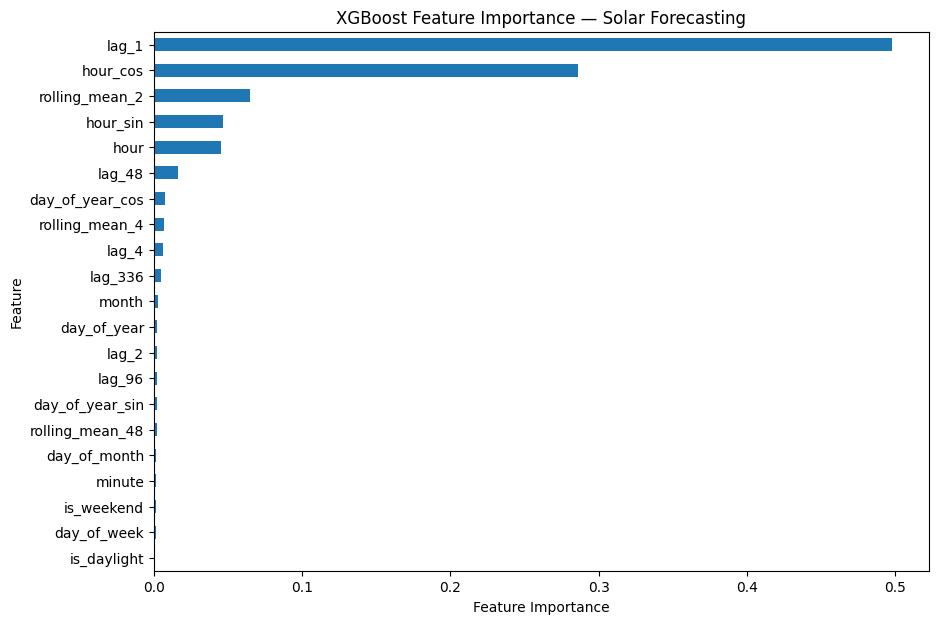

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 7))

importance.sort_values().plot(kind="barh")

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance — Solar Forecasting")
plt.show()

In [ ]:
y_pred_test = xgb_model.predict(X_test)

test_mae = mean_absolute_error(y_test, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_r2 = r2_score(y_test, y_pred_test)

print("XGBoost Test")
print("MAE :", test_mae)
print("RMSE:", test_rmse)
print("R²  :", test_r2)

XGBoost Test
MAE : 3.397472083437557
RMSE: 7.1927349705755805
R²  : 0.964481375202565


XGBoost is clearly useful:

MAE improvement

4.445
4.445−3.397
	​

×100≈23.6%

So the average absolute error is about 23.6% lower than persistence.

RMSE improvement

≈13.1%

And R² increased from roughly 0.953 → 0.9645.

So our first model has passed the most important sanity check:

XGBoost generalizes to the completely unseen later portion of the year and beats the persistence baseline.

In [ ]:
results = solar.loc[X_test.index, ["Timestamp", "Total_Solar_kWh"]].copy()

results["Actual"] = y_test.values
results["Predicted"] = y_pred_test
results["Error"] = results["Actual"] - results["Predicted"]
results["Absolute_Error"] = results["Error"].abs()

print(results.head(10))
print("\nError statistics:")
print(results["Error"].describe())

                Timestamp  Total_Solar_kWh   Actual   Predicted      Error  \
14605 2013-05-08 06:30:00            0.019    0.601    1.118301  -0.517301   
14606 2013-05-08 07:00:00            0.601   11.012    4.406752   6.605248   
14607 2013-05-08 07:30:00           11.012   26.113   15.741484  10.371516   
14608 2013-05-08 08:00:00           26.113   35.490   46.449043 -10.959043   
14609 2013-05-08 08:30:00           35.490   50.488   69.685074 -19.197074   
14610 2013-05-08 09:00:00           50.488   54.040   80.793442 -26.753442   
14611 2013-05-08 09:30:00           54.040   62.899   87.542496 -24.643496   
14612 2013-05-08 10:00:00           62.899   86.889   83.660568   3.228432   
14613 2013-05-08 10:30:00           86.889   94.528   91.176430   3.351570   
14614 2013-05-08 11:00:00           94.528  106.262  104.914238   1.347762   

       Absolute_Error  
14605        0.517301  
14606        6.605248  
14607       10.371516  
14608       10.959043  
14609       19.197074

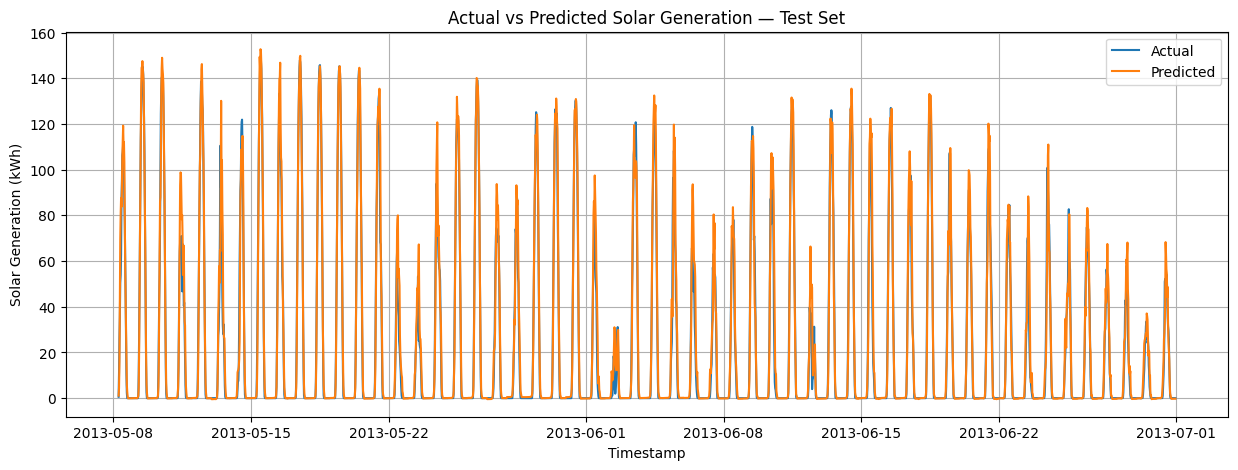

In [ ]:
plt.figure(figsize=(15, 5))

plt.plot(
    results["Timestamp"],
    results["Actual"],
    label="Actual"
)

plt.plot(
    results["Timestamp"],
    results["Predicted"],
    label="Predicted"
)

plt.xlabel("Timestamp")
plt.ylabel("Solar Generation (kWh)")
plt.title("Actual vs Predicted Solar Generation — Test Set")
plt.legend()
plt.grid(True)
plt.show()

Time       Actual    Predicted    Error
06:30       0.601      1.118       -0.52
07:00      11.012      4.407        6.61
07:30      26.113     15.741       10.37
08:00      35.490     46.449      -10.96
08:30      50.488     69.685      -19.20
09:00      54.040     80.793      -26.75
09:30      62.899     87.542      -24.64
10:00      86.889     83.661        3.23
This shows the model has difficulty during rapid changes in solar generation, particularly around sunrise.

Mean error       = -1.58 kWh
Median error     = -0.018 kWh
Minimum error    = -45.72 kWh
Maximum error    = +46.23 kWh

The XGBoost model accurately captures the general daily solar-generation profile but exhibits larger errors during rapid generation transitions, particularly around sunrise and other periods of sharp change.

In [ ]:
results["Generation_Level"] = pd.cut(
    results["Actual"],
    bins=[-0.01, 1, 20, 60, float("inf")],
    labels=["Low", "Medium", "High", "Very High"]
)

level_metrics = results.groupby("Generation_Level", observed=True).apply(
    lambda x: pd.Series({
        "MAE": x["Absolute_Error"].mean(),
        "RMSE": np.sqrt(np.mean(x["Error"] ** 2)),
        "Count": len(x)
    })
)

print(level_metrics)

                       MAE       RMSE   Count
Generation_Level                             
Low               0.360553   0.930462  1565.0
Medium            5.906807   8.169572   249.0
High              8.952891  12.301628   331.0
Very High         8.684102  12.281350   433.0


/tmp/ipykernel_523/1521090358.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  level_metrics = results.groupby("Generation_Level", observed=True).apply(


In [ ]:
results["Hour"] = results["Timestamp"].dt.hour

hour_mae = (
    results.groupby("Hour")["Absolute_Error"]
    .mean()
)

print(hour_mae)

Hour
0      0.098608
1      0.099099
2      0.098403
3      0.100287
4      0.107431
5      0.153926
6      0.580753
7      3.563711
8      5.999610
9      6.270529
10     9.981166
11     9.903291
12    11.163600
13    13.301162
14     8.184279
15     4.884850
16     4.643529
17     1.128190
18     0.163558
19     0.154323
20     0.144569
21     0.134878
22     0.132815
23     0.125066
Name: Absolute_Error, dtype: float64


Our model's overall:

MAE  = 3.397 kWh
RMSE = 7.193 kWh
R²   = 0.9645

looks excellent.

But the hour-wise analysis reveals that overall metrics hide important operational behaviour.

For the RL agent, a 10 kWh error during nighttime isn't meaningful because solar is essentially zero anyway.

A 10–13 kWh error around midday is much more consequential because that's when the grid has substantial renewable generation available.

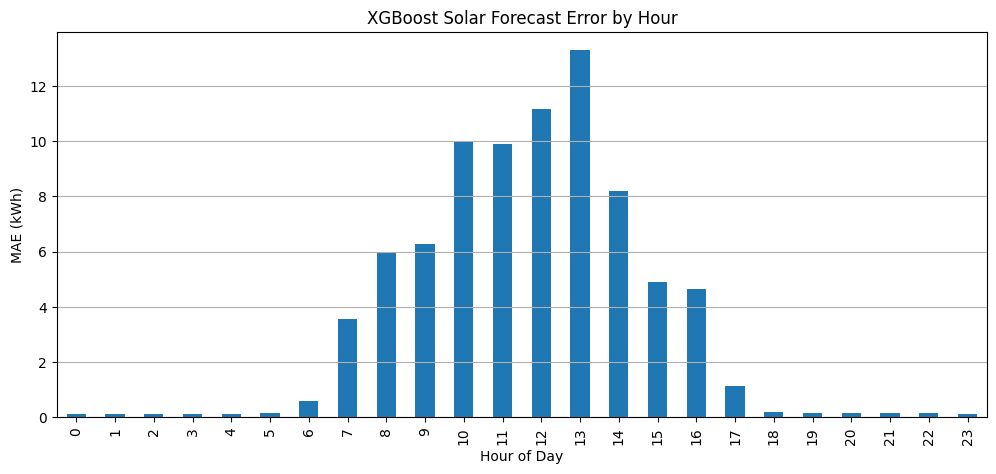

In [ ]:
plt.figure(figsize=(12, 5))

hour_mae.plot(kind="bar")

plt.xlabel("Hour of Day")
plt.ylabel("MAE (kWh)")
plt.title("XGBoost Solar Forecast Error by Hour")
plt.grid(axis="y")
plt.show()

In [ ]:
bias_by_level = results.groupby(
    "Generation_Level",
    observed=True
)["Error"].mean()

print(bias_by_level)

Generation_Level
Low         -0.217065
Medium      -4.904158
High        -2.921729
Very High   -3.595438
Name: Error, dtype: float64


In [ ]:
#model 2
from xgboost import XGBRegressor

xgb_tuned = XGBRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    max_depth=5,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50
)

xgb_tuned.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print("Best iteration:", xgb_tuned.best_iteration)

Best iteration: 140


In [ ]:
y_pred_val_tuned = xgb_tuned.predict(X_val)

tuned_val_mae = mean_absolute_error(y_val, y_pred_val_tuned)
tuned_val_rmse = np.sqrt(
    mean_squared_error(y_val, y_pred_val_tuned)
)
tuned_val_r2 = r2_score(y_val, y_pred_val_tuned)

print("Tuned XGBoost Validation")

print("MAE :", tuned_val_mae)
print("RMSE:", tuned_val_rmse)
print("R²  :", tuned_val_r2)

Tuned XGBoost Validation
MAE : 4.080868594312187
RMSE: 7.408391256828246
R²  : 0.9810788515050781


In [ ]:
import lightgbm as lgb

print(lgb.__version__)

4.6.0


In [ ]:
from lightgbm import LGBMRegressor

lgb_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)]
)

print("LightGBM training complete.")

LightGBM training complete.


In [ ]:
y_pred_val_lgb = lgb_model.predict(X_val)

lgb_val_mae = mean_absolute_error(y_val, y_pred_val_lgb)
lgb_val_rmse = np.sqrt(
    mean_squared_error(y_val, y_pred_val_lgb)
)
lgb_val_r2 = r2_score(y_val, y_pred_val_lgb)

print("LightGBM Validation")
print("MAE :", lgb_val_mae)
print("RMSE:", lgb_val_rmse)
print("R²  :", lgb_val_r2)

LightGBM Validation
MAE : 3.8414811338398254
RMSE: 7.436588269515487
R²  : 0.98093454617393


In [ ]:
from xgboost import XGBRegressor

final_xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

final_xgb.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print("Final XGBoost trained.")

Final XGBoost trained.


In [ ]:
y_pred_final = final_xgb.predict(X_test)

final_mae = mean_absolute_error(y_test, y_pred_final)
final_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_final)
)
final_r2 = r2_score(y_test, y_pred_final)

print("FINAL XGBoost TEST RESULTS")
print("MAE :", final_mae)
print("RMSE:", final_rmse)
print("R²  :", final_r2)

FINAL XGBoost TEST RESULTS
MAE : 3.397472083437557
RMSE: 7.1927349705755805
R²  : 0.964481375202565


In [ ]:
import joblib

joblib.dump(
    final_xgb,
    "solar_xgboost_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [ ]:
solar_predictions = pd.DataFrame({
    "Timestamp": solar.loc[X_test.index, "Timestamp"].values,
    "Predicted_Solar_kWh": y_pred_final
})
print(solar_predictions.head(10))
print("\nShape:", solar_predictions.shape)
print("\nMissing values:")
print(solar_predictions.isna().sum())

            Timestamp  Predicted_Solar_kWh
0 2013-05-08 06:30:00             1.118301
1 2013-05-08 07:00:00             4.406752
2 2013-05-08 07:30:00            15.741484
3 2013-05-08 08:00:00            46.449043
4 2013-05-08 08:30:00            69.685074
5 2013-05-08 09:00:00            80.793442
6 2013-05-08 09:30:00            87.542496
7 2013-05-08 10:00:00            83.660568
8 2013-05-08 10:30:00            91.176430
9 2013-05-08 11:00:00           104.914238

Shape: (2578, 2)

Missing values:
Timestamp              0
Predicted_Solar_kWh    0
dtype: int64


In [ ]:
print("\nPrediction statistics:")
print(solar_predictions["Predicted_Solar_kWh"].describe())

print("\nNegative predictions:")
print((solar_predictions["Predicted_Solar_kWh"] < 0).sum())


Prediction statistics:
count    2578.000000
mean       24.002686
std        39.638012
min        -0.453890
25%        -0.032883
50%         0.425382
75%        34.102411
max       152.685028
Name: Predicted_Solar_kWh, dtype: float64

Negative predictions:
765


In [ ]:
solar_predictions["Predicted_Solar_kWh"] = (
    solar_predictions["Predicted_Solar_kWh"].clip(lower=0)
)

In [ ]:
print("Negative predictions after clipping:")
print(
    (solar_predictions["Predicted_Solar_kWh"] < 0).sum()
)

print("\nPrediction statistics:")
print(
    solar_predictions["Predicted_Solar_kWh"].describe()
)

Negative predictions after clipping:
0

Prediction statistics:
count    2578.000000
mean       24.040211
std        39.615288
min         0.000000
25%         0.000000
50%         0.425382
75%        34.102411
max       152.685028
Name: Predicted_Solar_kWh, dtype: float64


In [ ]:
solar_predictions.to_csv(
    "solar_predictions.csv",
    index=False
)

print("Solar prediction file saved successfully!")
print("Shape:", solar_predictions.shape)

Solar prediction file saved successfully!
Shape: (2578, 2)


In [ ]:
import os

print("File exists:", os.path.exists("solar_predictions.csv"))
print(
    "File size:",
    os.path.getsize("solar_predictions.csv") / (1024 * 1024),
    "MB"
)

File exists: True
File size: 0.06984710693359375 MB
